# Auditoría 1 — ¿La marginal $p_t$ de train coincide con la del sampler?

**Pregunta:** para un mismo $t$, ¿la marginal $p_t(x_t \mid x_0)$ que se usa al entrenar es la misma que la que usa (implícitamente) el sampler?

**Mapa del código (quién calcula qué):**

- **Train:** `dsm_loss` (`training/losses.py:50-51`) llama a `sde.perturb` y `sde.score_target` (`sde/base.py:165` y `:193`), y **ambos derivan todo de `marginal_prob`**. Es la única fuente de la marginal en entrenamiento.
- **Sampler:** ningún sampler llama a `marginal_prob` (verificado por grep). Consumen la SDE por otra vía: los drifts reversos usan `sde.sde()` — los coeficientes $(f, g)$ — (`samplers/base.py:185-215`), y el arranque usa `prior_sampling` (`samplers/base.py:152`).

O sea: **no hay dos cálculos de la marginal que puedan divergir por un bug de duplicación** — hay una sola implementación y el sampler ni la toca. La pregunta se transforma en: ¿son **mutuamente consistentes** `marginal_prob` (lo que vio la red al entrenar) con `sde()` + `prior_sampling` (lo que integra el sampler)? Si no lo fueran, el sampler estaría revirtiendo *otro* proceso distinto del que la red aprendió.

Cuatro chequeos: **(1)** identidad de momentos entre `marginal_prob` y `sde()`; **(2)** integrar el forward con Euler–Maruyama usando solo `sde()` y comparar contra `marginal_prob`; **(3)** el caso VE cerca de $t=0$; **(4)** el prior en $t=T$ (que también es una marginal) contra la marginal real en $T$.

In [1]:
# --- Setup: bootstrap de sys.path + imports + estilo de ploteo ---
import sys
import pathlib

# El pythonpath del pyproject solo aplica a pytest, no al kernel de Jupyter.
_here = pathlib.Path.cwd()
_root = None
for _cand in (_here, *_here.parents):
    if (_cand / "src" / "diffusion").is_dir():
        _root = _cand
        break
if _root is None:
    raise RuntimeError(f"No encontré src/diffusion subiendo desde {_here}")
sys.path.insert(0, str(_root / "src"))

import numpy as np
import torch
import matplotlib.pyplot as plt

from diffusion.sde import make_sde
from diffusion.data_generation import make_distribution

torch.manual_seed(0)

# Paleta categórica accesible (orden fijo) + tinta/grilla recesivas.
SDE_COLORS = {"vp": "#2a78d6", "ve": "#008300", "sub_vp": "#e87ba4"}
C_A, C_B = "#2a78d6", "#008300"   # par genérico para series 'train' vs 'sampler'
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
plt.rcParams.update({
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})
SDES = ["vp", "ve", "sub_vp"]
print("raíz del paquete:", _root)

raíz del paquete: c:\Users\bravo\Facultad\calculo-estocastico\tp-final\diffusion-models


## Chequeo 1 — Identidad de momentos entre `marginal_prob` y `sde()`

Las tres SDEs son lineales: $dx = a(t)\,x\,dt + g(t)\,dW$. Para un proceso así, la media y la varianza del kernel obedecen las ODEs de momentos (Fokker–Planck):

$$\frac{dm}{dt} = a(t)\,m, \qquad \frac{dV}{dt} = 2\,a(t)\,V + g(t)^2.$$

Si `marginal_prob` (train) y `sde()` (sampler) describen **el mismo proceso**, estas identidades tienen que cumplirse punto a punto. Las verificamos en `float64` con diferencias finitas centradas sobre toda la grilla $t \in [10^{-3}, 1]$ — la misma franja que visitan el entrenamiento y el sampler.

In [2]:
h = 1e-5
t = torch.linspace(1e-3 + h, 1.0 - h, 800, dtype=torch.float64)
x0 = torch.full((t.shape[0], 2), 1.7, dtype=torch.float64)

def coeffs(sde, t):
    """a(t) y g(t) de dx = a(t)·x·dt + g(t)·dW, evaluados con x=1 (SDEs lineales)."""
    ones = torch.ones(t.shape[0], 2, dtype=torch.float64)
    f, g = sde.sde(ones, t)
    a = f[:, :1]                       # f(1, t) = a(t)
    g = g * torch.ones_like(a)         # broadcast a (B, 1) por si g llega escalar
    return a, g

print(f"{'SDE':8s} {'max |err| dV/dt':>16s} {'max err rel':>12s} {'max |err| dm/dt':>16s}")
for name in SDES:
    sde = make_sde(name)
    mean_p, std_p = sde.marginal_prob(x0, t + h)
    mean_m, std_m = sde.marginal_prob(x0, t - h)
    mean_c, std_c = sde.marginal_prob(x0, t)
    dV = (std_p**2 - std_m**2) / (2 * h)
    dm = (mean_p - mean_m) / (2 * h)
    a, g = coeffs(sde, t)
    rhs_V = 2.0 * a * std_c**2 + g**2
    rhs_m = a * mean_c
    err_V = (dV - rhs_V).abs().max().item()
    rel_V = ((dV - rhs_V).abs() / rhs_V.abs().clamp_min(1e-12)).max().item()
    err_m = (dm - rhs_m).abs().max().item()
    print(f"{name:8s} {err_V:16.3e} {rel_V:12.3e} {err_m:16.3e}")

SDE       max |err| dV/dt  max err rel  max |err| dm/dt
vp              2.049e-09    1.327e-08        1.237e-09
ve              7.985e-07    2.578e-09        0.000e+00
sub_vp          2.726e-09    8.944e-06        1.237e-09


## Chequeo 2 — Integrar el forward con los coeficientes del sampler y comparar

Ahora la versión empírica, sin identidades: partimos de un $x_0$ fijo (una delta) y **simulamos el forward con Euler–Maruyama usando exclusivamente `sde.sde()`** — la misma interfaz que consumen los samplers. En varios $t$ comparamos la media y el desvío empíricos de la nube contra lo que `marginal_prob` dice que la red vio al entrenar en ese mismo $t$.

In [3]:
N, STEPS = 20_000, 2_000
x0_val = torch.tensor([1.5, -0.8])
ts_check = [0.001, 0.01, 0.05, 0.25, 0.5, 1.0]
gen = torch.Generator().manual_seed(123)

emp = {}
for name in SDES:
    sde = make_sde(name)
    x = x0_val.expand(N, 2).clone()
    grid = torch.linspace(0.0, 1.0, STEPS + 1)
    std_curve = [0.0]
    snap, ti, targets = {}, 0, sorted(ts_check)
    for i in range(STEPS):
        t_cur = grid[i].expand(N)
        dt = (grid[i + 1] - grid[i]).item()
        f, g = sde.sde(x, t_cur)
        z = torch.randn(x.shape, generator=gen)
        x = x + f * dt + g * (dt ** 0.5) * z
        mu = x.mean(dim=0)
        std_curve.append(((x - mu) ** 2).mean().sqrt().item())
        t_next = grid[i + 1].item()
        while ti < len(targets) and t_next >= targets[ti] - 1e-9:
            snap[targets[ti]] = (mu.clone(), std_curve[-1])
            ti += 1
    emp[name] = (grid.numpy(), np.array(std_curve), snap)

for name in SDES:
    sde = make_sde(name)
    print(f"--- {name} ---")
    _, _, snap = emp[name]
    for tv in ts_check:
        mu_e, std_e = snap[tv]
        mean_th, std_th = sde.marginal_prob(x0_val.unsqueeze(0), torch.full((1,), tv))
        print(f"  t={tv:5.3f}  mean EM=({mu_e[0]:+.4f},{mu_e[1]:+.4f})"
              f" vs marginal=({mean_th[0,0]:+.4f},{mean_th[0,1]:+.4f})"
              f" | std EM={std_e:.4f} vs marginal={std_th.item():.4f}")

--- vp ---
  t=0.001  mean EM=(+1.4999,-0.8001) vs marginal=(+1.4999,-0.8000) | std EM=0.0102 vs marginal=0.0105
  t=0.010  mean EM=(+1.4982,-0.7992) vs marginal=(+1.4985,-0.7992) | std EM=0.0443 vs marginal=0.0446
  t=0.050  mean EM=(+1.4766,-0.7861) vs marginal=(+1.4778,-0.7881) | std EM=0.1710 vs marginal=0.1716
  t=0.250  mean EM=(+1.0875,-0.5701) vs marginal=(+1.0855,-0.5789) | std EM=0.6897 vs marginal=0.6902
  t=0.500  mean EM=(+0.4119,-0.2230) vs marginal=(+0.4218,-0.2249) | std EM=0.9594 vs marginal=0.9597
  t=1.000  mean EM=(+0.0031,-0.0171) vs marginal=(+0.0099,-0.0053) | std EM=1.0024 vs marginal=1.0000
--- ve ---
  t=0.001  mean EM=(+1.5000,-0.8000) vs marginal=(+1.5000,-0.8000) | std EM=0.0011 vs marginal=0.0101
  t=0.010  mean EM=(+1.5000,-0.8000) vs marginal=(+1.5000,-0.8000) | std EM=0.0036 vs marginal=0.0106
  t=0.050  mean EM=(+1.5000,-0.8000) vs marginal=(+1.5000,-0.8000) | std EM=0.0093 vs marginal=0.0136
  t=0.250  mean EM=(+1.5005,-0.8004) vs marginal=(+1.5000,-0

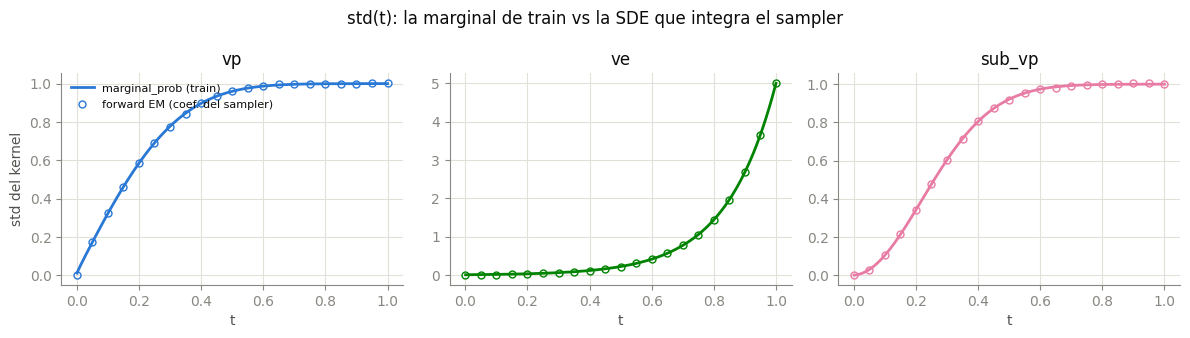

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharex=True)
tt = torch.linspace(1e-3, 1.0, 400)
for ax, name in zip(axes, SDES):
    sde = make_sde(name)
    _, std_th = sde.marginal_prob(x0_val.expand(tt.shape[0], 2), tt)
    color = SDE_COLORS[name]
    grid_t, std_e, _ = emp[name]
    ax.plot(tt.numpy(), std_th[:, 0].numpy(), color=color, lw=2, label="marginal_prob (train)")
    ax.plot(grid_t[::100], std_e[::100], "o", mfc="none", mec=color, ms=5,
            label="forward EM (coef. del sampler)")
    ax.set_title(name, color=INK)
    ax.set_xlabel("t")
axes[0].set_ylabel("std del kernel")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle("std(t): la marginal de train vs la SDE que integra el sampler", color=INK)
fig.tight_layout()
plt.show()

## Chequeo 3 — VE cerca de $t=0$: la convención $\sigma_{min}$

En la tabla anterior VE muestra la única discrepancia: en $t$ chico, `std EM` ≪ `std marginal`. No es un bug de tipeo sino una **convención heredada de Song et al.**: para VE, `marginal_prob` devuelve $\sigma(t) = \sigma_{min}(\sigma_{max}/\sigma_{min})^t$, cuya varianza en $t=0$ es $\sigma_{min}^2 > 0$ — **no una delta en el dato**. La SDE integrada desde el dato limpio acumula $\int_0^t g^2 = \sigma^2(t) - \sigma_{min}^2$. Ambas coinciden **solo si** se asume que el proceso arranca de $p_0 = p_{data} \ast \mathcal{N}(0, \sigma_{min}^2 I)$: el dato ya lleva ruido $\sigma_{min}$ puesto.

Consecuencia práctica: la red de VE nunca aprende el score del dato limpio sino del dato $\ast\,\mathcal{N}(0, \sigma_{min}^2)$, y las muestras generadas en $t_{eps}$ retienen ruido residual de escala $\sigma(t_{eps}) \approx \sigma_{min} = 0.01$. Para VP y sub-VP no pasa: su varianza en $t=0$ es exactamente $0$.

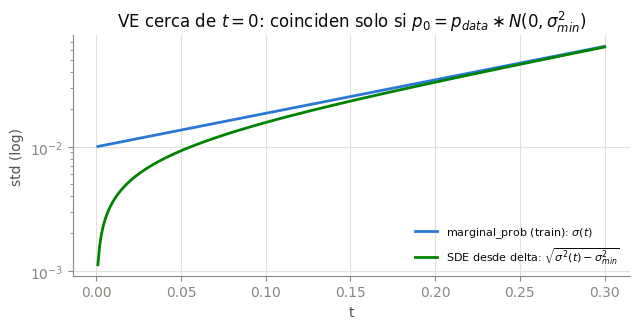

     t  std train  std desde delta   ratio
 0.001    0.01006          0.00112    9.00
 0.005    0.01032          0.00253    4.07
 0.010    0.01064          0.00364    2.93
 0.050    0.01364          0.00928    1.47
 0.100    0.01862          0.01570    1.19
 0.300    0.06452          0.06374    1.01


In [ ]:
sde = make_sde("ve")
tt = torch.linspace(1e-3, 0.3, 300)
_, std_tr = sde.marginal_prob(torch.zeros(tt.shape[0], 2), tt)
std_tr = std_tr[:, 0].numpy()
std_delta = np.sqrt(np.clip(std_tr**2 - sde.sigma_min**2, 0.0, None))

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(tt, std_tr, color=C_A, lw=2, label="marginal_prob (train): $\\sigma(t)$")
ax.plot(tt, std_delta, color=C_B, lw=2,
        label="SDE desde delta: $\\sqrt{\\sigma^2(t)-\\sigma_{min}^2}$")
ax.set_yscale("log")
ax.set_xlabel("t")
ax.set_ylabel("std (log)")
ax.set_title("VE cerca de $t=0$: coinciden solo si $p_0 = p_{data} \\ast N(0, \\sigma_{min}^2)$", color=INK)
ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

print(f"{'t':>6s} {'std train':>10s} {'std desde delta':>16s} {'ratio':>7s}")
for tv in [1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 3e-1]:
    s_tr = float(sde.marginal_prob(torch.zeros(1, 2), torch.full((1,), tv))[1])
    s_de = max(s_tr**2 - sde.sigma_min**2, 0.0) ** 0.5
    print(f"{tv:6.3f} {s_tr:10.5f} {s_de:16.5f} {s_tr / max(s_de, 1e-12):7.2f}")

## Chequeo 4 — El prior en $t=T$ también es una marginal (y acá hay un hallazgo)

El sampler arranca de `prior_sampling` — $\mathcal{N}(0, I)$ para VP/sub-VP, $\mathcal{N}(0, \sigma_{max}^2 I)$ para VE. Pero la marginal **real** del forward en $T$ es $\mathcal{N}(\alpha(T)\,x_0,\ \sigma(T)^2 I)$: tiene una **media que depende del dato** y que el prior ignora. Ese es el único punto del pipeline donde train y sampler usan marginales *distintas por diseño*, y cuánto difieren depende de la SDE y de la escala del dato:

- **VP / sub-VP:** $\alpha(T) = e^{-5.025} \approx 0.0066$ aplasta la media — el offset es despreciable.
- **VE:** $\alpha \equiv 1$, la media es $x_0$ **entero**. El offset relativo es $\|x_0\| / \sigma_{max}$.

Medimos con la mezcla de 8 gaussianas en sus dos variantes: **sin estandarizar** (radio 5 — es lo que entrena el `config/vp_mixture.yaml` committeado, que no pasa `standardize`) y **estandarizada** (la del notebook 01). Referencia de Song (*Improved techniques for training SBGM*): elegir $\sigma_{max} \geq$ distancia máxima entre pares del dataset.

In [ ]:
print(f"{'SDE':8s} {'standardize':>12s} {'||mean(T)|| medio':>18s} {'std(T)':>8s} {'std prior':>10s} {'offset/std':>11s}")
for standardize in (False, True):
    dist = make_distribution("mixture", dim=2, n_components=8, standardize=standardize, seed=0)
    x0_data = torch.from_numpy(dist.sample(20_000))
    for name in SDES:
        sde = make_sde(name)
        tT = torch.full((x0_data.shape[0],), sde.T)
        mean_T, std_T = sde.marginal_prob(x0_data, tT)
        offset = mean_T.norm(dim=1).mean().item()
        prior = sde.prior_sampling((50_000, 2), generator=torch.Generator().manual_seed(7))
        prior_std = prior.std().item()
        print(f"{name:8s} {str(standardize):>12s} {offset:18.4f} {std_T.mean().item():8.4f}"
              f" {prior_std:10.4f} {offset / prior_std:11.4f}")

print()
for standardize in (False, True):
    dist = make_distribution("mixture", dim=2, n_components=8, standardize=standardize, seed=0)
    x0_data = torch.from_numpy(dist.sample(4_000))
    d_max = torch.cdist(x0_data, x0_data).max().item()
    print(f"mixture standardize={standardize}: distancia máxima entre pares ≈ {d_max:.2f}"
          f"  (regla de Song: sigma_max >= esto; sigma_max actual de VE = {make_sde('ve').sigma_max})")

SDE       standardize  ||mean(T)|| medio   std(T)  std prior  offset/std
vp              False             0.0329   1.0000     0.9997      0.0329
ve              False             5.0099   5.0000     4.9984      1.0023
sub_vp          False             0.0329   1.0000     0.9997      0.0329
vp               True             0.0093   1.0000     0.9997      0.0093
ve               True             1.4117   5.0000     4.9984      0.2824
sub_vp           True             0.0093   1.0000     0.9997      0.0093

mixture standardize=False: distancia máxima entre pares ≈ 12.03  (regla de Song: sigma_max >= esto; sigma_max actual de VE = 5.0)
mixture standardize=True: distancia máxima entre pares ≈ 3.40  (regla de Song: sigma_max >= esto; sigma_max actual de VE = 5.0)


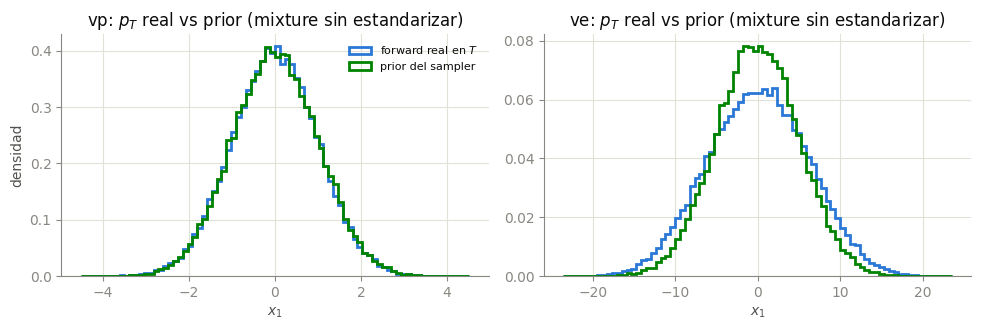

In [ ]:
# La foto del hallazgo: densidad de la coordenada x1 en t=T — forward real vs prior del sampler,
# con la mezcla SIN estandarizar (la del YAML committeado).
gen = torch.Generator().manual_seed(7)
dist = make_distribution("mixture", dim=2, n_components=8, standardize=False, seed=0)
x0_data = torch.from_numpy(dist.sample(50_000))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, name in zip(axes, ["vp", "ve"]):
    sde = make_sde(name)
    tT = torch.full((x0_data.shape[0],), sde.T)
    xT, _ = sde.perturb(x0_data, tT, generator=gen)      # marginal real en T (vía marginal_prob)
    prior = sde.prior_sampling((x0_data.shape[0], 2), generator=gen)
    lim = float(max(xT[:, 0].abs().max(), prior[:, 0].abs().max()))
    bins = np.linspace(-lim, lim, 81)
    ax.hist(xT[:, 0].numpy(), bins=bins, density=True, histtype="step", lw=2,
            color=C_A, label="forward real en $T$")
    ax.hist(prior[:, 0].numpy(), bins=bins, density=True, histtype="step", lw=2,
            color=C_B, label="prior del sampler")
    ax.set_title(f"{name}: $p_T$ real vs prior (mixture sin estandarizar)", color=INK)
    ax.set_xlabel("$x_1$")
axes[0].set_ylabel("densidad")
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## Conclusiones

**Respuesta corta: sí, para un mismo $t$ interior la marginal es la misma en train y en el sampler — con dos salvedades, ambas de VE.**

1. **No hay duplicación de código que pueda divergir.** `marginal_prob` se calcula en un solo lugar; el training la consume vía `perturb`/`score_target` y los samplers no la usan — usan `sde()` y `prior_sampling`.
2. **VP y sub-VP: consistencia exacta.** La identidad de momentos $dV/dt = 2aV + g^2$ se cumple a precisión de máquina en toda la grilla, y el forward integrado con los coeficientes del sampler reproduce media y desvío de `marginal_prob` en todos los $t$ chequeados. El rango temporal también cierra: el training muestrea $t \in [t_{eps}, T]$ y el sampler visita $[t_{eps}, T]$ — la red nunca se evalúa fuera de donde entrenó.
3. **VE, salvedad chica (convención $\sigma_{min}$, esperada):** la marginal de train presupone $p_0 = p_{data} \ast \mathcal{N}(0, \sigma_{min}^2 I)$; cerca de $t=0$ difiere de la SDE-desde-delta (ratio ~9× en $t=10^{-3}$, <2% en $t \geq 0.3$). Es la convención estándar de Song et al.; su único efecto visible es ruido residual $\approx \sigma_{min} = 0.01$ en las muestras finales.
4. **VE, salvedad grande (el prior en $T$):** el sampler arranca de $\mathcal{N}(0, \sigma_{max}^2)$ pero la marginal real en $T$ es $\mathcal{N}(x_0, \sigma_{max}^2)$. Con la mezcla **sin estandarizar** (radio 5, que es lo que entrena `config/vp_mixture.yaml` al no pasar `standardize`) el offset medio de media es $\approx 1.0 \cdot \sigma_{prior}$ — enorme — y la distancia máxima entre pares (~12) **duplica** el $\sigma_{max}=5$ actual, violando la regla de Song. El docstring de `VESDE` justifica el default 5.0 con "escala del toy data 2D **estandarizado**", supuesto que el config committeado no cumple. Con la mezcla estandarizada el offset baja a ~0.28·σ y $\sigma_{max}=5$ vuelve a ser razonable. **Si hay resultados malos de VE sobre la mixture cruda, este es el sospechoso número 1** — y no lo arregla ningún sampler, porque es un desajuste del punto de partida compartido por los cuatro.

Para VP/sub-VP el mismo chequeo del prior da offset ≈ 0.03·σ: despreciable.